In [1]:
import math
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

FAST = True

SEED = 20260907

SNR_DB = np.arange(-12.0, 3.0, 1.0)
KNEE_DB = (-12.0, -4.0)

# ANE bank size. Must be even when ANTITHETIC=True.
K = 8

# ---------------- Observation length ----------------
N_SAMPLES = 64

# Rayleigh (Fourier) resolution limit in rad.
RAYLEIGH = 2.0 * np.pi / N_SAMPLES

PAIR_PRESETS = {
    "recommended": dict(center_pi=0.41, sep_pi=0.02),
    "midband_alt": dict(center_pi=0.43, sep_pi=0.06),
    "upper_78_80": dict(center_pi=0.79, sep_pi=0.02),
    "upper_80_82": dict(center_pi=0.81, sep_pi=0.02),
}

PAIR_CHOICE = "midband_alt"

CENTER_PI = PAIR_PRESETS[PAIR_CHOICE]["center_pi"]
SEP_PI = PAIR_PRESETS[PAIR_CHOICE]["sep_pi"]

PHI1_TRUE = (CENTER_PI - 0.5 * SEP_PI) * np.pi
PHI2_TRUE = (CENTER_PI + 0.5 * SEP_PI) * np.pi

# ---------------- Training ----------------
ALPHA_GRID = np.array(
    [0.0, 0.15, 0.30, 0.45, 0.60, 0.80, 1.0, 1.5, 2.2, 3.0, 4.0],
    dtype=float,
)

TRAIN_L = 3000 if FAST else 40000
TRAIN_L_KNEE = 12000 if FAST else 60000

REFINE = True
REFINE_DB = (0.0, 16.0)
REFINE_ITERS = 15 if FAST else 80

VAL_FRAC = 1.0
SIG_Z = 3.0
MIN_REL_GAIN = 0.02

MAX_NORM_SIG = 4.0
ZERO_MEAN = True
ANTITHETIC = True

# ---------------- Frequency search ----------------
GRID_NLS = 1024
GRID_MMSE_2D = 401

MMSE_GRID_AUTO_OFFSET = True
MMSE_GRID_OFFSET_TRIALS = 401
MMSE_MIN_NODE_DIST = 0.20

MMSE_CAND_CHUNK = 2048
MMSE_CACHE_BYTES = 256 * 1024 * 1024

# ---------------- MMSE local refinement ----------------
MMSE_REFINE = True
MMSE_REFINE_PASSES = 3
MMSE_REFINE_POINTS = 21
MMSE_REFINE_SHRINK = 0.35
MMSE_REFINE_SAMPLE_CHUNK = 256

MMSE_FLAT_FALLBACK = False
MMSE_FLAT_ENTROPY = 0.90

NEWTON_STEPS_2D = 5
NEWTON_MAX_STEP_GRID = 2.0
NEWTON_BACKTRACK = 8

# ---------------- Monte Carlo ----------------
MC_BATCH_PT = 4000
MC_MAX = 100000 if FAST else 400000
MC_TOL = 0.05
MC_MIN_OUT = 10

TRIALS = 4000 if FAST else 100000
TRIALS_KNEE = 12000 if FAST else 200000

In [2]:
# ============================================================
# 2. REPRODUCIBILITY AND UTILITY FUNCTIONS
# ============================================================

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def project_bank(Z, sigma):
    Z = np.asarray(Z, dtype=float).copy()
    if ZERO_MEAN:
        Z -= Z.mean(axis=0, keepdims=True)
    nrm = np.linalg.norm(Z, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scale = np.minimum(1.0, cap / np.maximum(nrm, 1e-12))
    return Z * scale

def make_antithetic_directions(K, N, seed=11):
    if K % 2 != 0:
        raise ValueError("K must be even for an antithetic bank.")
    H = K // 2
    rng = np.random.default_rng(seed)
    V = rng.standard_normal((H, N))
    V -= V.mean(axis=0, keepdims=True)
    V /= np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-12)
    return np.concatenate([V, -V], axis=0)

def make_directions(K, N, seed=11):
    rng = np.random.default_rng(seed)
    U = rng.standard_normal((K, N))
    U -= U.mean(axis=0, keepdims=True)
    U /= np.maximum(np.linalg.norm(U, axis=1, keepdims=True), 1e-12)
    return U

def symmetrize_bank(Z, sigma):
    Z = np.asarray(Z, dtype=float)
    if not ANTITHETIC:
        return project_bank(Z, sigma)
    Kb, N = Z.shape
    if Kb % 2 != 0:
        raise ValueError("Antithetic bank requires even K.")
    H = Kb // 2
    V = 0.5 * (Z[:H] - Z[H:])
    raw_norm = np.linalg.norm(V, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scale = np.minimum(1.0, cap / np.maximum(raw_norm, 1e-12))
    V = V * scale
    return np.concatenate([V, -V], axis=0)

def safe_rel_gain(plain, improved):
    if plain <= 0:
        return 0.0
    return 100.0 * (plain - improved) / plain

In [5]:
# ============================================================
# 3. TWO-FREQUENCY MODEL
# ============================================================

class TwoFreqModel:
    name = "Two closely-spaced tones"
    unit = "rad"

    def __init__(
        self,
        N=N_SAMPLES,
        phi1_true=PHI1_TRUE,
        phi2_true=PHI2_TRUE,
        grid_nls=GRID_NLS,
        grid_mmse_2d=GRID_MMSE_2D,
        auto_offset=MMSE_GRID_AUTO_OFFSET,
    ):
        if not phi1_true < phi2_true:
            raise ValueError("Require phi1_true < phi2_true.")

        self.N = int(N)
        self.nvec = np.arange(1, N + 1, dtype=float)
        self.phi1_true = float(phi1_true)
        self.phi2_true = float(phi2_true)
        self.theta_true = np.array([self.phi1_true, self.phi2_true], dtype=float)

        self.lo = 1e-3
        self.hi = np.pi - 1e-3

        self.PHI_GRID = np.linspace(self.lo, self.hi, grid_nls)
        self.S_GRID = np.cos(np.outer(self.nvec, self.PHI_GRID))
        self.S_NORM2 = np.sum(self.S_GRID ** 2, axis=0)
        self.BIN = self.PHI_GRID[1] - self.PHI_GRID[0]
        self.rayleigh = 2.0 * np.pi / self.N
        self.peak_excl = max(1, int(round(0.5 * self.rayleigh / self.BIN)))
        self.anom = self.rayleigh

        G2 = int(grid_mmse_2d)
        self.G2 = G2
        span = self.hi - self.lo
        self.grid_step = span / G2
        self.grid_offset = self._choose_grid_offset(auto_offset)

        self.PHI_GRID2 = (
            self.lo + self.grid_offset + np.arange(G2, dtype=float) * self.grid_step
        )
        ia, ib = np.triu_indices(G2, k=1)
        self.IA = ia.astype(np.int64)
        self.IB = ib.astype(np.int64)
        self.M_CAND = int(self.IA.size)
        self.PARAM_MMSE = np.stack([self.PHI_GRID2[ia], self.PHI_GRID2[ib]], axis=1)

    def _choose_grid_offset(self, auto_offset):
        if not auto_offset:
            return 0.0
        step = self.grid_step
        best_delta = 0.5 * step
        best_dist = -1.0
        for f in np.linspace(0.0, 1.0, MMSE_GRID_OFFSET_TRIALS, endpoint=False):
            delta = f * step
            d = [abs((p - (self.lo + delta)) / step - round((p - (self.lo + delta)) / step)) for p in (self.phi1_true, self.phi2_true)]
            m = min(d)
            if m > best_dist:
                best_dist = m
                best_delta = delta
        return best_delta

    def prior_mean(self):
        span = self.hi - self.lo
        return np.array([self.lo + span / 3.0, self.lo + 2.0 * span / 3.0], dtype=float)

    def prior_floor(self):
        d = self.theta_true - self.prior_mean()
        return d ** 2, float(np.sum(d ** 2))

    def fim(self, sigma):
        n = self.nvec
        s1 = np.sin(n * self.phi1_true)
        s2 = np.sin(n * self.phi2_true)
        n2 = n ** 2
        J11 = np.sum(n2 * s1 * s1)
        J22 = np.sum(n2 * s2 * s2)
        J12 = np.sum(n2 * s1 * s2)
        return np.array([[J11, J12], [J12, J22]], dtype=float) / (sigma ** 2)

    def crb(self, sigma):
        J = self.fim(sigma)
        C = np.linalg.inv(J)
        diag = np.array([C[0, 0], C[1, 1]], dtype=float)
        return diag, float(np.sum(diag))

    @staticmethod
    def sigma_of(gamma):
        return 1.0 / np.sqrt(2.0 * gamma)

    def sigma_of_snr(self, snr_db):
        return self.sigma_of(10.0 ** (snr_db / 10.0))

    def gen(self, trials, sigma, rng):
        s = np.cos(self.nvec * self.phi1_true) + np.cos(self.nvec * self.phi2_true)
        X = s[None, :] + sigma * rng.standard_normal((trials, self.N))
        theta = np.broadcast_to(self.theta_true, (trials, 2)).copy()
        return theta, X

    def _peak_pick_init(self, X):
        cost = -2.0 * (X @ self.S_GRID) + self.S_NORM2[None, :]
        score = -cost
        idx1 = np.argmax(score, axis=1)
        _, G = score.shape
        cols = np.arange(G)
        lo_idx = np.clip(idx1 - self.peak_excl, 0, G - 1)
        hi_idx = np.clip(idx1 + self.peak_excl, 0, G - 1)
        mask = (cols[None, :] >= lo_idx[:, None]) & (cols[None, :] <= hi_idx[:, None])
        score2 = np.where(mask, -np.inf, score)
        idx2 = np.argmax(score2, axis=1)
        phi_a = self.PHI_GRID[idx1]
        phi_b = self.PHI_GRID[idx2]
        return np.minimum(phi_a, phi_b), np.maximum(phi_a, phi_b)

    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec
        a1, a2 = np.outer(phi1, n), np.outer(phi2, n)
        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)
        r = X - (c1 + c2)
        n2 = n[None, :] ** 2
        g1 = 2.0 * np.sum(r * n[None, :] * s1, axis=1)
        g2 = 2.0 * np.sum(r * n[None, :] * s2, axis=1)
        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)
        return g1, g2, H11, H22, H12

    def nls_cost(self, X, theta):
        phi1, phi2 = theta[:, 0], theta[:, 1]
        n = self.nvec[None, :]
        r = X - (np.cos(phi1[:, None] * n) + np.cos(phi2[:, None] * n))
        return np.sum(r * r, axis=1)

    def nls_batch(self, X):
        phi1, phi2 = self._peak_pick_init(X)
        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)
            det = H11 * H22 - H12 ** 2
            det_safe = np.where(np.abs(det) > 1e-10, det, np.where(det >= 0.0, 1e-10, -1e-10))
            d1 = (H22 * g1 - H12 * g2) / det_safe
            d2 = (H11 * g2 - H12 * g1) / det_safe
            max_step = NEWTON_MAX_STEP_GRID * self.BIN
            d1, d2 = np.clip(d1, -max_step, max_step), np.clip(d2, -max_step, max_step)
            old1, old2 = phi1.copy(), phi2.copy()
            old_cost = self.nls_cost(X, np.stack([old1, old2], axis=1))
            accepted = np.zeros(X.shape[0], dtype=bool)
            step = np.ones(X.shape[0], dtype=float)
            for _bt in range(NEWTON_BACKTRACK):
                cand1 = np.clip(old1 - step * d1, self.lo, self.hi)
                cand2 = np.clip(old2 - step * d2, self.lo, self.hi)
                cand_cost = self.nls_cost(X, np.stack([cand1, cand2], axis=1))
                good = cand_cost <= old_cost
                update = good & (~accepted)
                phi1[update], phi2[update] = cand1[update], cand2[update]
                accepted |= good
                step *= 0.5
                if np.all(accepted):
                    break
            phi1[~accepted], phi2[~accepted] = old1[~accepted], old2[~accepted]
        return np.stack([np.minimum(phi1, phi2), np.maximum(phi1, phi2)], axis=1)

    def dtheta_dx(self, X, th):
        phi1, phi2 = th[:, 0], th[:, 1]
        n = self.nvec
        a1, a2 = np.outer(phi1, n), np.outer(phi2, n)
        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)
        r = X - (c1 + c2)
        n2 = n[None, :] ** 2
        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)
        det = H11 * H22 - H12 ** 2
        det_safe = np.where(np.abs(det) > 1e-10, det, np.where(det >= 0.0, 1e-10, -1e-10))
        A1, A2 = 2.0 * n[None, :] * s1, 2.0 * n[None, :] * s2
        J1 = -(H22[:, None] * A1 - H12[:, None] * A2) / det_safe[:, None]
        J2 = -(H11[:, None] * A2 - H12[:, None] * A1) / det_safe[:, None]
        return np.stack([J1, J2], axis=1)

In [6]:
# ============================================================
# 4. ANE FUNCTIONS
# ============================================================

def ane_batch_2f(model, X, Z, th_plain=None):
    Kb = Z.shape[0]
    if np.allclose(Z, 0.0):
        th = model.nls_batch(X) if th_plain is None else th_plain
        return th.copy(), np.repeat(th[:, None, :], Kb, axis=1)
    outs = np.stack([model.nls_batch(X + Z[k][None, :]) for k in range(Kb)], axis=1)
    return outs.mean(axis=1), outs

def train_bank_at_snr_2f(
    model, K, sigma, U, Z_warm, refine, L_fit, rng, tag="", gdb=0.0
):
    # 【核心修改点 1】：当 SNR >= 0dB 时，直接返回全0扰动跳过训练
    if gdb >= 0.0:
        print(
            f"  [{tag}] plain ----- | "
            f"val-gain  +0.0% | spread 0.00 | MAP-fallback (>=0dB)"
        )
        return np.zeros((K, model.N), dtype=float)

    L_val = max(4000, int(VAL_FRAC * L_fit))
    theta_f, X_f = model.gen(L_fit, sigma, rng)
    theta_v, X_v = model.gen(L_val, sigma, rng)

    thp_f = model.nls_batch(X_f)
    thp_v = model.nls_batch(X_v)
    plain_f = float(np.mean((thp_f - theta_f) ** 2))
    plain_v = float(np.mean((thp_v - theta_v) ** 2))

    best_Z = np.zeros((K, model.N), dtype=float)
    best = plain_f

    for alpha in ALPHA_GRID[1:]:
        Z = project_bank(alpha * sigma * U, sigma)
        if ANTITHETIC:
            Z = symmetrize_bank(Z, sigma)
        v = float(np.mean((ane_batch_2f(model, X_f, Z, thp_f)[0] - theta_f) ** 2))
        if v < best:
            best, best_Z = v, Z.copy()

    status, gain_v = "zero", 0.0
    if best < plain_f and not np.allclose(best_Z, 0.0):
        pred_v, _ = ane_batch_2f(model, X_v, best_Z, thp_v)
        ev_mse = np.mean((pred_v - theta_v) ** 2, axis=1)
        ep_mse = np.mean((thp_v - theta_v) ** 2, axis=1)
        d = ev_mse - ep_mse
        se = float(d.std(ddof=1)) / math.sqrt(L_val)
        t_ok = float(d.mean()) < -SIG_Z * se

        Bp = np.any(np.abs(thp_v - theta_v) > model.anom, axis=1)
        Ba = np.any(np.abs(pred_v - theta_v) > model.anom, axis=1)
        n10, n01 = int(np.sum(Bp & ~Ba)), int(np.sum(~Bp & Ba))
        mc_stat = (n10 - n01) / math.sqrt(max(n10 + n01, 1))
        mc_ok = mc_stat > SIG_Z
        gain_v = safe_rel_gain(plain_v, float(np.mean(ev_mse)))

        if (t_ok or mc_ok) and gain_v >= 100.0 * MIN_REL_GAIN:
            status = "accepted(" + ("t" if t_ok else "mc") + ")"
        else:
            best_Z, gain_v, status = np.zeros((K, model.N), dtype=float), 0.0, "rejected(ns)"

    a_eff = float(np.mean(np.linalg.norm(best_Z, axis=1))) / max(sigma, 1e-12)
    print(
        f"  [{tag}] plain {plain_v:.3e} | "
        f"val-gain {gain_v:+5.1f}% | "
        f"spread {a_eff:4.2f} | {status}"
    )
    return best_Z

def train_all_snr_2f(model, gam, knee, seed0, snr_db=None):
    if snr_db is None:
        snr_db = SNR_DB
    U = make_antithetic_directions(K, model.N, seed=11 + K) if ANTITHETIC else make_directions(K, model.N, seed=11 + K)
    banks = [None for _ in range(len(snr_db))]
    Zw, prev_sigma = None, None

    print("\n" + "=" * 62)
    print(f"ANE training: {model.name}, K={K}, antithetic={ANTITHETIC}")
    print("=" * 62)

    for i, gdb in enumerate(snr_db):
        sigma = model.sigma_of(gam[i])
        if Zw is not None and prev_sigma is not None:
            Zw = Zw * sigma / prev_sigma
        L_fit = TRAIN_L_KNEE if knee[i] else TRAIN_L
        refine = REFINE and REFINE_DB[0] <= gdb <= REFINE_DB[1]
        banks[i] = train_bank_at_snr_2f(
            model=model, K=K, sigma=sigma, U=U, Z_warm=Zw,
            refine=refine, L_fit=L_fit, rng=np.random.default_rng(seed0 + i),
            tag=f"{model.unit} {gdb:+5.1f}dB", gdb=gdb
        )
        Zw, prev_sigma = banks[i], sigma
    return banks

In [7]:
# ============================================================
# 5. PYTORCH EVALUATOR
# ============================================================

class PyTorchEvaluator2F:
    def __init__(self, model, device=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device is None else torch.device(device)
        self.N, self.lo, self.hi = model.N, model.lo, model.hi
        self.BIN, self.peak_excl, self.anom = model.BIN, model.peak_excl, model.anom
        self.grid_step, self.M_CAND = model.grid_step, model.M_CAND
        dtype = torch.float64
        self.dtype = dtype

        self.nvec = torch.tensor(model.nvec, device=self.device, dtype=dtype)
        self.PHI_GRID = torch.tensor(model.PHI_GRID, device=self.device, dtype=dtype)
        self.S_GRID = torch.tensor(model.S_GRID, device=self.device, dtype=dtype)
        self.S_NORM2 = torch.tensor(model.S_NORM2, device=self.device, dtype=dtype)
        self.PHI_GRID2 = torch.tensor(model.PHI_GRID2, device=self.device, dtype=dtype)
        self.IA = torch.tensor(model.IA, device=self.device, dtype=torch.long)
        self.IB = torch.tensor(model.IB, device=self.device, dtype=torch.long)
        self.theta_true = torch.tensor(model.theta_true, device=self.device, dtype=dtype)

        cache_bytes = self.M_CAND * self.N * 8
        self.cached = cache_bytes <= MMSE_CACHE_BYTES
        if self.cached:
            th = torch.stack([self.PHI_GRID2[self.IA], self.PHI_GRID2[self.IB]], dim=1)
            S = torch.cos(th[:, 0:1] * self.nvec.unsqueeze(0)) + torch.cos(th[:, 1:2] * self.nvec.unsqueeze(0))
            self.TH_CAND, self.S_CAND, self.S2_CAND = th, S, torch.sum(S * S, dim=1)

    @torch.no_grad()
    def gen_batch(self, batch_size, sigma, theta_true=None):
        if theta_true is None:
            theta_true = self.theta_true
        s = torch.cos(self.nvec * theta_true[0]) + torch.cos(self.nvec * theta_true[1])
        noise = torch.randn(batch_size, self.N, device=self.device, dtype=self.dtype) * sigma
        X = s.unsqueeze(0) + noise
        theta = theta_true.unsqueeze(0).expand(batch_size, -1).clone()
        return theta, X

    @torch.no_grad()
    def _peak_pick_init(self, X):
        cost = -2.0 * torch.matmul(X, self.S_GRID) + self.S_NORM2.unsqueeze(0)
        score = -cost
        idx1 = torch.argmax(score, dim=1)
        G = score.shape[1]
        cols = torch.arange(G, device=self.device).unsqueeze(0)
        lo_idx = torch.clamp(idx1 - self.peak_excl, 0, G - 1).unsqueeze(1)
        hi_idx = torch.clamp(idx1 + self.peak_excl, 0, G - 1).unsqueeze(1)
        mask = (cols >= lo_idx) & (cols <= hi_idx)
        score2 = score.masked_fill(mask, float("-inf"))
        idx2 = torch.argmax(score2, dim=1)
        return torch.minimum(self.PHI_GRID[idx1], self.PHI_GRID[idx2]), torch.maximum(self.PHI_GRID[idx1], self.PHI_GRID[idx2])

    def signal(self, theta):
        n = self.nvec.unsqueeze(0)
        return torch.cos(theta[:, 0].unsqueeze(1) * n) + torch.cos(theta[:, 1].unsqueeze(1) * n)

    def nls_cost(self, X, theta):
        r = X - self.signal(theta)
        return torch.sum(r * r, dim=1)

    @torch.no_grad()
    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec.unsqueeze(0)
        a1, a2 = phi1.unsqueeze(1) * n, phi2.unsqueeze(1) * n
        s1, c1 = torch.sin(a1), torch.cos(a1)
        s2, c2 = torch.sin(a2), torch.cos(a2)
        r = X - (c1 + c2)
        n2 = n ** 2
        g1 = 2.0 * torch.sum(r * n * s1, dim=1)
        g2 = 2.0 * torch.sum(r * n * s2, dim=1)
        H11 = 2.0 * torch.sum(n2 * (s1 ** 2 + r * c1), dim=1)
        H22 = 2.0 * torch.sum(n2 * (s2 ** 2 + r * c2), dim=1)
        H12 = 2.0 * torch.sum(n2 * (s1 * s2), dim=1)
        return g1, g2, H11, H22, H12

    @torch.no_grad()
    def _safeguarded_newton(self, X, phi1, phi2):
        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)
            det = H11 * H22 - H12 ** 2
            det_safe = torch.where(torch.abs(det) > 1e-10, det, torch.where(det >= 0, torch.full_like(det, 1e-10), torch.full_like(det, -1e-10)))
            d1, d2 = (H22 * g1 - H12 * g2) / det_safe, (H11 * g2 - H12 * g1) / det_safe
            max_step = NEWTON_MAX_STEP_GRID * self.BIN
            d1, d2 = torch.clamp(d1, -max_step, max_step), torch.clamp(d2, -max_step, max_step)
            old1, old2 = phi1.clone(), phi2.clone()
            old_cost = self.nls_cost(X, torch.stack([old1, old2], dim=1))
            accepted = torch.zeros(X.shape[0], device=X.device, dtype=torch.bool)
            step = torch.ones_like(d1)
            for _bt in range(NEWTON_BACKTRACK):
                cand1 = torch.clamp(old1 - step * d1, self.lo, self.hi)
                cand2 = torch.clamp(old2 - step * d2, self.lo, self.hi)
                cand_cost = self.nls_cost(X, torch.stack([cand1, cand2], dim=1))
                good = cand_cost <= old_cost
                update = good & (~accepted)
                phi1, phi2 = torch.where(update, cand1, phi1), torch.where(update, cand2, phi2)
                accepted |= good
                step *= 0.5
                if bool(torch.all(accepted)):
                    break
            phi1, phi2 = torch.where(accepted, phi1, old1), torch.where(accepted, phi2, old2)
        return torch.minimum(phi1, phi2), torch.maximum(phi1, phi2)

    @torch.no_grad()
    def nls_batch(self, X):
        phi1, phi2 = self._peak_pick_init(X)
        phi1, phi2 = self._safeguarded_newton(X, phi1, phi2)
        return torch.stack([phi1, phi2], dim=1)

    def _candidate_chunk(self, c0, c1):
        if self.cached:
            return self.TH_CAND[c0:c1], self.S_CAND[c0:c1], self.S2_CAND[c0:c1]
        ia, ib = self.IA[c0:c1], self.IB[c0:c1]
        th = torch.stack([self.PHI_GRID2[ia], self.PHI_GRID2[ib]], dim=1)
        S = torch.cos(th[:, 0:1] * self.nvec.unsqueeze(0)) + torch.cos(th[:, 1:2] * self.nvec.unsqueeze(0))
        return th, S, torch.sum(S * S, dim=1)

    @torch.no_grad()
    def _posterior_scan(self, X, inv2s2, want_mean=True, want_entropy=False):
        B, dev, dt = X.shape[0], X.device, X.dtype
        best_val = torch.full((B,), -float("inf"), device=dev, dtype=dt)
        best_th = torch.zeros(B, 2, device=dev, dtype=dt)
        run_max = torch.full((B,), -float("inf"), device=dev, dtype=dt)
        run_z = torch.zeros(B, device=dev, dtype=dt)
        run_m1 = torch.zeros(B, 2, device=dev, dtype=dt)
        run_m2 = torch.zeros(B, 2, device=dev, dtype=dt)

        for c0 in range(0, self.M_CAND, MMSE_CAND_CHUNK):
            c1 = min(c0 + MMSE_CAND_CHUNK, self.M_CAND)
            th_c, S_c, S2_c = self._candidate_chunk(c0, c1)
            lw = (2.0 * torch.matmul(X, S_c.transpose(0, 1)) - S2_c.unsqueeze(0)) * inv2s2
            v, i = torch.max(lw, dim=1)
            upd = v > best_val
            best_val = torch.where(upd, v, best_val)
            best_th = torch.where(upd.unsqueeze(1), th_c[i], best_th)

            if not want_mean:
                continue
            new_max = torch.maximum(run_max, v)
            scale = torch.exp(run_max - new_max)
            scale = torch.where(torch.isfinite(run_max), scale, torch.zeros_like(scale))
            e = torch.exp(lw - new_max.unsqueeze(1))
            run_z = run_z * scale + e.sum(dim=1)
            run_m1 = run_m1 * scale.unsqueeze(1) + e @ th_c
            run_m2 = run_m2 * scale.unsqueeze(1) + e @ (th_c * th_c)
            run_max = new_max

        out = {"argmax": best_th}
        if want_mean:
            zsafe = torch.clamp(run_z, min=1e-300)
            mean = run_m1 / zsafe.unsqueeze(1)
            second = run_m2 / zsafe.unsqueeze(1)
            var = torch.clamp(second - mean * mean, min=0.0)
            out["mean"] = mean
            out["std"] = torch.sqrt(var)
        return out

    @torch.no_grad()
    def mle_and_mmse(self, X, sigma, refine=None):
        if refine is None:
            refine = MMSE_REFINE
        X = X.to(self.dtype)
        sigma_t = torch.clamp(torch.as_tensor(sigma, dtype=self.dtype, device=X.device), min=1e-12)
        inv2s2 = 1.0 / (2.0 * sigma_t * sigma_t)

        scan = self._posterior_scan(X, inv2s2, want_mean=True, want_entropy=MMSE_FLAT_FALLBACK)
        theta0 = scan["argmax"]
        phi1, phi2 = self._safeguarded_newton(X, theta0[:, 0].clone(), theta0[:, 1].clone())
        th_mle = torch.stack([phi1, phi2], dim=1)

        theta_mmse = scan["mean"]
        if not refine:
            return th_mle, theta_mmse

        hw_floor = max(3.0 * float(sigma_t.item()) / (float(self.N) ** 1.5), 1e-6)
        half_w = torch.clamp(scan["std"], min=hw_floor, max=4.0 * self.grid_step)
        
        # Local refine batched
        B, F = X.shape[0], MMSE_REFINE_POINTS
        t = torch.linspace(-1.0, 1.0, F, device=X.device, dtype=X.dtype).unsqueeze(0)
        n = self.nvec.view(1, 1, -1)
        max_hw = 4.0 * self.grid_step
        out = theta_mmse.clone()
        chunk = max(1, int(MMSE_REFINE_SAMPLE_CHUNK))

        for b0 in range(0, B, chunk):
            b1 = min(b0 + chunk, B)
            xb, cb, hb = X[b0:b1], theta_mmse[b0:b1].clone(), half_w[b0:b1].clone()
            bs = b1 - b0
            for _pass in range(MMSE_REFINE_PASSES):
                g0 = torch.clamp(cb[:, 0:1] + t * hb[:, 0:1], self.lo, self.hi)
                g1 = torch.clamp(cb[:, 1:2] + t * hb[:, 1:2], self.lo, self.hi)
                th0 = g0.unsqueeze(2).expand(bs, F, F).reshape(bs, F * F)
                th1 = g1.unsqueeze(1).expand(bs, F, F).reshape(bs, F * F)
                valid = th0 < th1
                S = torch.cos(th0.unsqueeze(2) * n) + torch.cos(th1.unsqueeze(2) * n)
                S2 = torch.sum(S * S, dim=2)
                lw = (2.0 * torch.einsum("bn,bmn->bm", xb, S) - S2) * inv2s2
                lw = torch.where(valid, lw, torch.full_like(lw, -1e30))
                p = torch.softmax(lw, dim=1)
                any_valid = valid.any(dim=1)
                th_stack = torch.stack([th0, th1], dim=2)
                new_c = torch.sum(p.unsqueeze(2) * th_stack, dim=1)
                new_var = torch.sum(p.unsqueeze(2) * (th_stack - new_c.unsqueeze(1)) ** 2, dim=1)
                new_hw = torch.clamp(torch.sqrt(torch.clamp(new_var, min=0.0)), min=hw_floor, max=max_hw)
                new_hw = torch.clamp(new_hw * MMSE_REFINE_SHRINK, min=hw_floor)
                keep = any_valid.unsqueeze(1)
                cb = torch.where(keep, new_c, cb)
                hb = torch.where(keep, new_hw, torch.clamp(hb * MMSE_REFINE_SHRINK, min=hw_floor))
            out[b0:b1] = cb

        return th_mle, out

    @torch.no_grad()
    def ane_batch(self, X, Z):
        Kb = Z.shape[0]
        if torch.all(torch.abs(Z) < 1e-15):
            return self.nls_batch(X)
        outs = [self.nls_batch(X + Z[k].unsqueeze(0)) for k in range(Kb)]
        outs = torch.stack(outs, dim=1)
        return torch.mean(outs, dim=1)

# ============================================================
# 6. MONTE CARLO ACCUMULATION
# ============================================================

def new_acc():
    return {"c0": [0.0, 0.0, 0], "c1": [0.0, 0.0, 0], "joint": [0.0, 0.0, 0], "anom": 0, "n": 0}

def update_acc(acc, e_tensor, anom):
    for ci, key in enumerate(["c0", "c1"]):
        e = e_tensor[:, ci]
        e2 = e * e
        a = acc[key]
        a[0] += float(e2.sum().item())
        a[1] += float((e2 * e2).sum().item())
        a[2] += int(e.numel())
    joint_sq = torch.sum(e_tensor * e_tensor, dim=1)
    acc["joint"][0] += float(joint_sq.sum().item())
    acc["joint"][1] += float((joint_sq * joint_sq).sum().item())
    acc["joint"][2] += int(joint_sq.numel())
    anomaly = (torch.abs(e_tensor) > anom).any(dim=1)
    acc["anom"] += int(anomaly.sum().item())
    acc["n"] += int(e_tensor.shape[0])

def mse_se(a):
    n = max(a[2], 1)
    m = a[0] / n
    variance = max(a[1] / n - m * m, 0.0)
    se = math.sqrt(variance / n)
    return m, se

def _mc_converged(acc, names, need_outliers):
    if need_outliers and acc["nls"]["anom"] < MC_MIN_OUT:
        return False
    for name in names:
        for key in ("c0", "c1", "joint"):
            m, se = mse_se(acc[name][key])
            if m > 0.0 and se > MC_TOL * m:
                return False
    return True

def run_model_pytorch_2f(model, banks, gam, knee, snr_db=None):
    if snr_db is None:
        snr_db = SNR_DB
    pt_eval = PyTorchEvaluator2F(model)

    print("\n" + "=" * 62)
    print(f"Monte Carlo evaluation on {pt_eval.device}")
    print(
        f"posterior grid: {model.G2} nodes, "
        f"{model.M_CAND} ordered candidates, "
        f"cached={pt_eval.cached}"
    )
    print("=" * 62)

    names = ["nls", "mle", "mmse", "ane"]
    out = {}
    for name in names:
        for key in ["c0", "c1", "joint"]:
            out[f"mse_{name}_{key}"] = []
            out[f"mse_{name}_{key}_se"] = []
    out["crb_c0"], out["crb_c1"], out["crb_joint"] = [], [], []

    for i, gdb in enumerate(snr_db):
        sigma = model.sigma_of(gam[i])
        crb_c, crb_j = model.crb(sigma)
        out["crb_c0"].append(crb_c[0])
        out["crb_c1"].append(crb_c[1])
        out["crb_joint"].append(crb_j)

        n_min = TRIALS_KNEE if knee[i] else TRIALS
        if banks[i] is not None:
            Z_pt = torch.tensor(banks[i], device=pt_eval.device, dtype=pt_eval.dtype)
        else:
            Z_pt = torch.zeros(K, model.N, device=pt_eval.device, dtype=pt_eval.dtype)

        acc = {name: new_acc() for name in names}
        total = 0

        while total < MC_MAX:
            b = int(min(MC_BATCH_PT, MC_MAX - total))
            theta, X = pt_eval.gen_batch(b, sigma)

            # Local NLS
            th_nls = pt_eval.nls_batch(X)
            update_acc(acc["nls"], th_nls - theta, pt_eval.anom)

            # Global MLE (Equal to MAP under Uniform Prior) and MMSE
            th_mle, th_mmse = pt_eval.mle_and_mmse(X, sigma)
            update_acc(acc["mle"], th_mle - theta, pt_eval.anom)
            update_acc(acc["mmse"], th_mmse - theta, pt_eval.anom)

            # 【核心修改点 2】：当 SNR >= 0dB 时，ANE 估算直接强制等于 MAP
            if gdb >= 0.0:
                th_ane = th_mle
            else:
                th_ane = pt_eval.ane_batch(X, Z_pt)

            update_acc(acc["ane"], th_ane - theta, pt_eval.anom)

            total += b
            if _mc_converged(acc, names, need_outliers=(gdb in KNEE_DB)):
                if total >= n_min:
                    break

        print(
            f"SNR {gdb:+5.1f} dB | n={total:7d} | "
            f"nls: c0={mse_se(acc['nls']['c0'])[0]:.3e}, c1={mse_se(acc['nls']['c1'])[0]:.3e}, joint={mse_se(acc['nls']['joint'])[0]:.3e} | "
            f"mle: c0={mse_se(acc['mle']['c0'])[0]:.3e}, c1={mse_se(acc['mle']['c1'])[0]:.3e}, joint={mse_se(acc['mle']['joint'])[0]:.3e} | "
            f"mmse: c0={mse_se(acc['mmse']['c0'])[0]:.3e}, c1={mse_se(acc['mmse']['c1'])[0]:.3e}, joint={mse_se(acc['mmse']['joint'])[0]:.3e} | "
            f"ane: c0={mse_se(acc['ane']['c0'])[0]:.3e}, c1={mse_se(acc['ane']['c1'])[0]:.3e}, joint={mse_se(acc['ane']['joint'])[0]:.3e} | "
            f"outNLS={acc['nls']['anom']}"
        )

        for name in names:
            for key in ["c0", "c1", "joint"]:
                m, se = mse_se(acc[name][key])
                out[f"mse_{name}_{key}"].append(m)
                out[f"mse_{name}_{key}_se"].append(se)

    return out

In [8]:
# ============================================================
# 7. EXECUTION
# ============================================================
set_all_seeds(SEED)

model = TwoFreqModel()
gam = 10.0 ** (SNR_DB / 10.0)
knee = (SNR_DB >= KNEE_DB[0]) & (SNR_DB <= KNEE_DB[1])

banks = train_all_snr_2f(model, gam, knee, SEED)
res = run_model_pytorch_2f(model, banks, gam, knee)


ANE training: Two closely-spaced tones, K=8, antithetic=True
  [rad -12.0dB] plain 4.533e-01 | val-gain +36.3% | spread 4.00 | accepted(t)
  [rad -11.0dB] plain 3.891e-01 | val-gain +34.7% | spread 4.00 | accepted(t)
  [rad -10.0dB] plain 3.192e-01 | val-gain +33.4% | spread 4.00 | accepted(t)
  [rad  -9.0dB] plain 2.545e-01 | val-gain +33.1% | spread 4.00 | accepted(t)
  [rad  -8.0dB] plain 1.838e-01 | val-gain +31.7% | spread 4.00 | accepted(t)
  [rad  -7.0dB] plain 1.237e-01 | val-gain +27.7% | spread 3.00 | accepted(t)
  [rad  -6.0dB] plain 6.888e-02 | val-gain +28.4% | spread 3.00 | accepted(t)
  [rad  -5.0dB] plain 3.220e-02 | val-gain +23.7% | spread 2.20 | accepted(t)
  [rad  -4.0dB] plain 1.126e-02 | val-gain +23.4% | spread 2.20 | accepted(t)
  [rad  -3.0dB] plain 2.278e-03 | val-gain  +0.0% | spread 0.00 | rejected(ns)
  [rad  -2.0dB] plain 3.323e-04 | val-gain  +0.0% | spread 0.00 | rejected(ns)
  [rad  -1.0dB] plain 1.433e-05 | val-gain  +0.0% | spread 0.00 | rejected(ns)

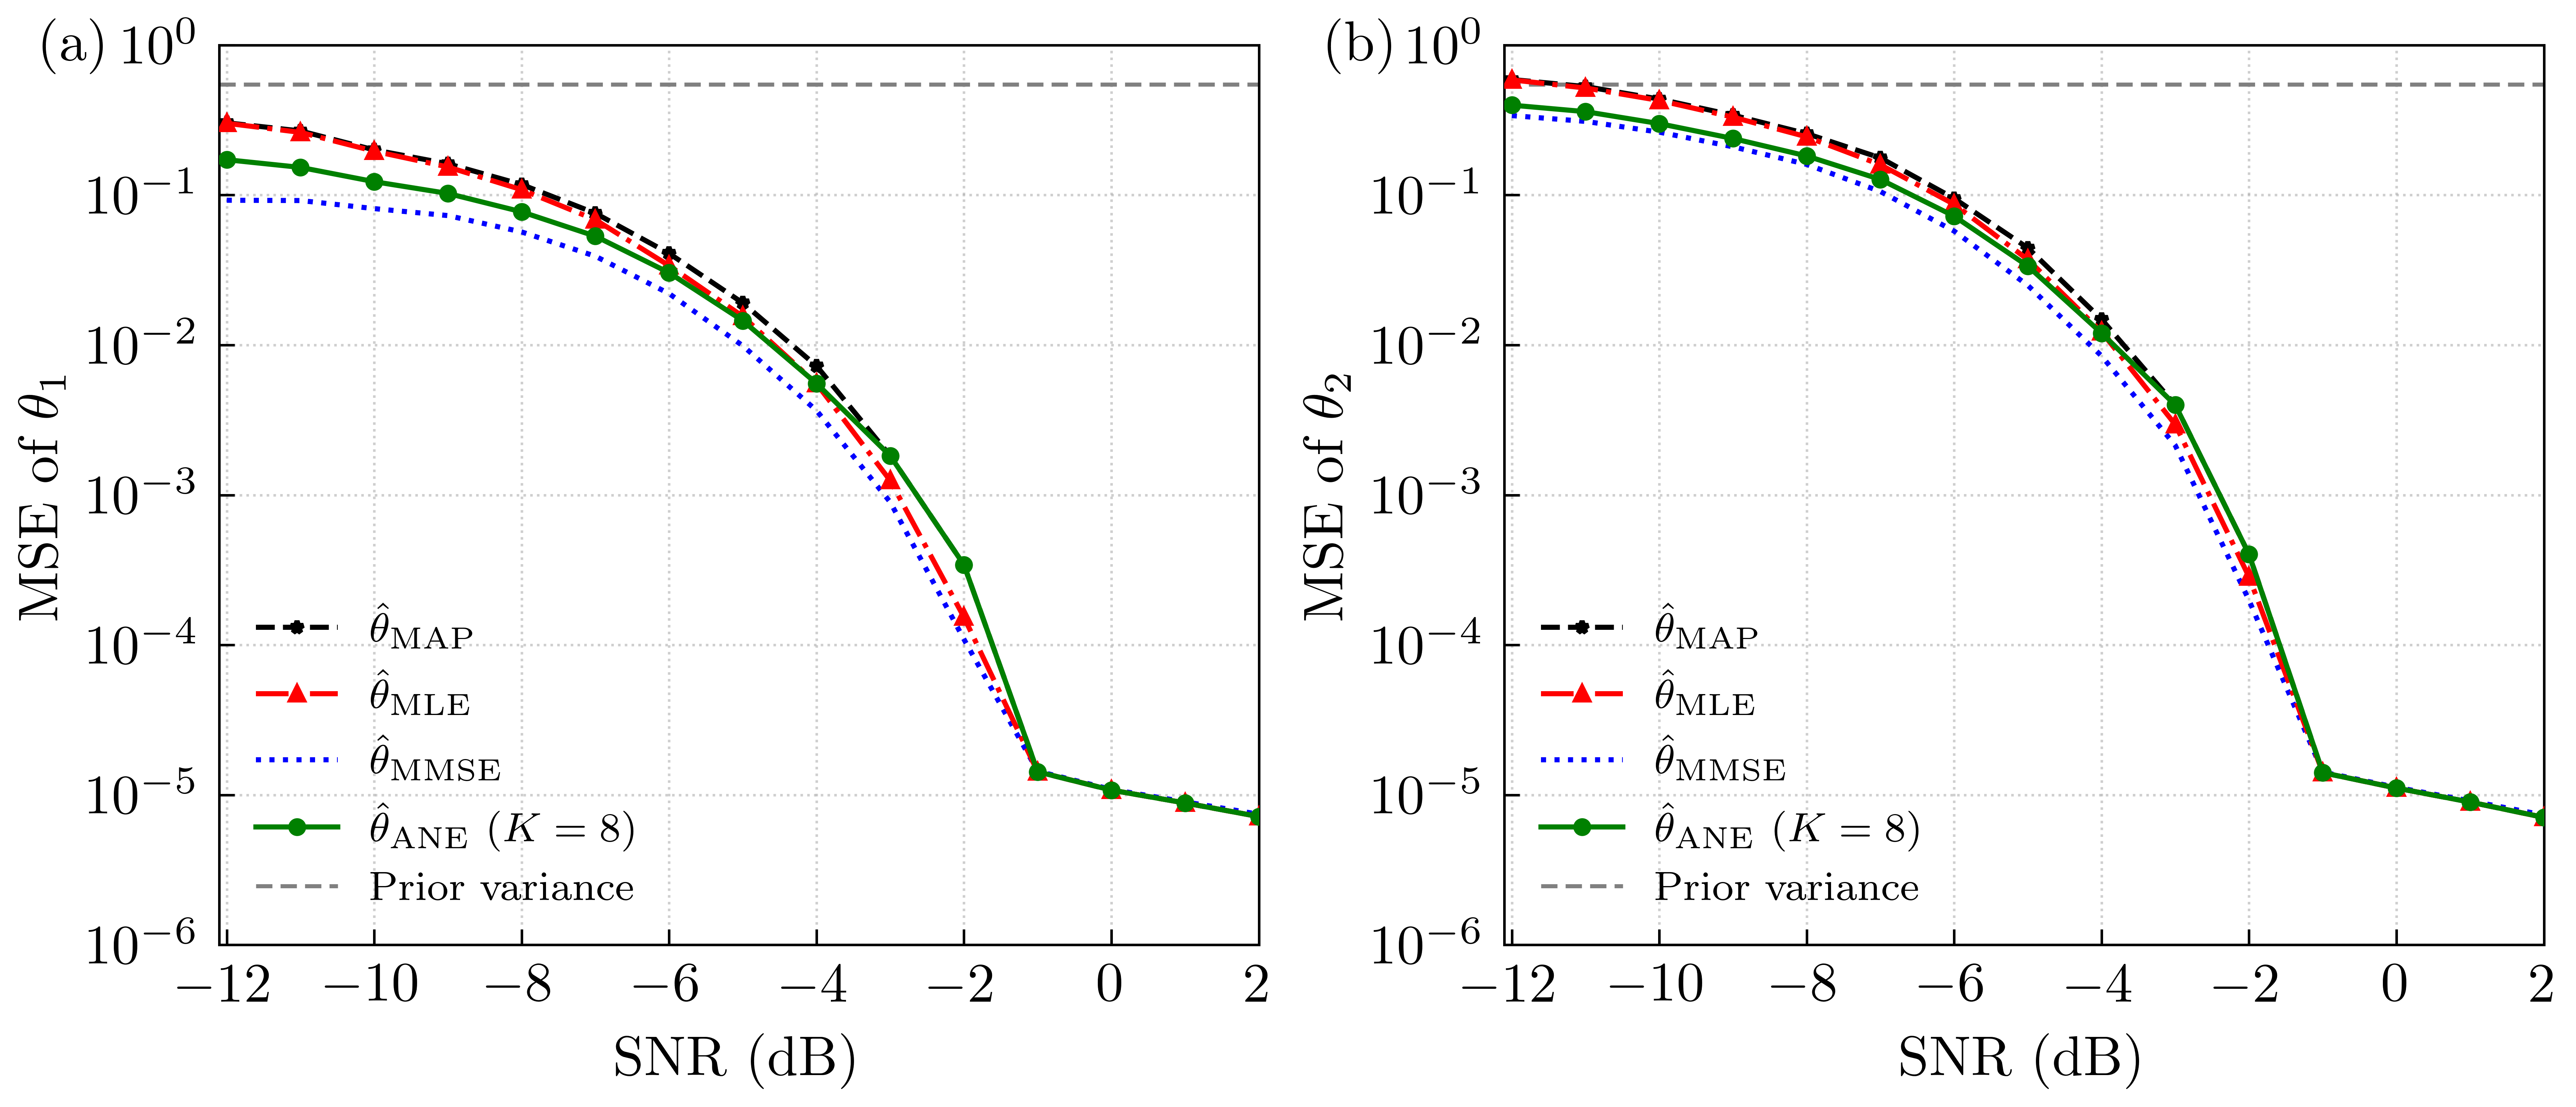

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# =========================================================================
# 将上一步的数据变量与绘图变量对齐
# =========================================================================
snr = SNR_DB
data = res

# =========================================================================
# Global academic style: SciencePlots + IEEE
# =========================================================================
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 8,
    'axes.labelsize'    : 8,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 1000,
    'axes.unicode_minus': False,
})

# =========================================================================
# Combined IEEE two-column figure
# =========================================================================
fig, (ax_s, ax_m) = plt.subplots(
    1, 2,
    figsize=(7, 3),
    constrained_layout=True
)

# =========================================================================
# (a) MSE of phi1 (c0)
# =========================================================================
ax_s.grid(True, which="both", alpha=0.25)
ax_s.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)

ax_s.semilogy(snr, data["mse_nls_c0"], label=r"$\hat\theta_{\mathrm{MAP}}$", marker="*", ms=2.5, zorder=4, linestyle="--", color="C0")
ax_s.semilogy(snr, data["mse_mle_c0"], label=r"$\hat\theta_{\mathrm{MLE}}$", marker="^", ms=2.5, zorder=4, linestyle="-.", color="C1")
ax_s.semilogy(snr, data["mse_mmse_c0"], label=r"$\hat\theta_{\mathrm{MMSE}}$", linestyle=":", color="C2")
ax_s.semilogy(snr, data["mse_ane_c0"], label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K=8)$", marker="o", ms=2.5, zorder=4, linestyle="-", color="C3")

# 先验下界：c0 的 prior-mean floor
ax_s.axhline(
    0.5483, 
    color="0.5", 
    linewidth=0.8, 
    linestyle=(0, (4, 2)), 
    label="Prior variance"
)

ax_s.set_xlabel("SNR (dB)", fontsize=11)
ax_s.set_ylabel(r"MSE of $\theta_1$", fontsize=11)
ax_s.tick_params(axis='both', labelsize=11)

ax_s.legend(
    loc="lower left",
    fontsize=8
)

# Panel label
ax_s.text(
    -0.17, 1.03,
    r'$\mathrm{(a)}$',
    transform=ax_s.transAxes,
    ha='left',
    va='top',
    fontsize=11
)
ax_s.set_xticks([-12, -10, -8, -6, -4, -2, 0, 2])
ax_s.set_xlim([-12.1, 2])
ax_s.set_ylim([0.000001, 1])

# 关闭 minor ticks
ax_s.minorticks_off()

# 只给主刻度画网格
ax_s.grid(which="major", ls=":", alpha=0.6)

# =========================================================================
# (b) MSE of phi2 (c1)
# =========================================================================
ax_m.grid(True, which="both", alpha=0.25)
ax_m.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)

ax_m.semilogy(snr, data["mse_nls_c1"], label=r"$\hat\theta_{\mathrm{MAP}}$", marker="*", ms=2.5, zorder=4, linestyle="--", color="C0")
ax_m.semilogy(snr, data["mse_mle_c1"], label=r"$\hat\theta_{\mathrm{MLE}}$", marker="^", ms=2.5, zorder=4, linestyle="-.", color="C1")
ax_m.semilogy(snr, data["mse_mmse_c1"], label=r"$\hat\theta_{\mathrm{MMSE}}$", linestyle=":", color="C2")
ax_m.semilogy(snr, data["mse_ane_c1"], label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K=8)$", marker="o", ms=2.5, zorder=4, linestyle="-", color="C3")

ax_m.axhline(
    0.5483, 
    color="0.5", 
    linewidth=0.8, 
    linestyle=(0, (4, 2)), 
    label="Prior variance"
)

ax_m.set_xlabel("SNR (dB)", fontsize=11)
ax_m.set_ylabel(r"MSE of $\theta_2$", fontsize=11)
ax_m.tick_params(axis='both', labelsize=11)

ax_m.legend(
    loc="lower left",
    fontsize=8
)

# Panel label
ax_m.text(
    -0.17, 1.03,
    r'$\mathrm{(b)}$',
    transform=ax_m.transAxes,
    ha='left',
    va='top',
    fontsize=11
)
ax_m.set_xticks([-12, -10, -8, -6, -4, -2, 0, 2])
ax_m.set_xlim([-12.1, 2])
ax_m.set_ylim([0.000001, 1])

# 关闭 minor ticks
ax_m.minorticks_off()

# 只给主刻度画网格
ax_m.grid(which="major", ls=":", alpha=0.6)

# =========================================================================
# Save & Show
# =========================================================================
fig.savefig("D:/Fig3-1.pdf", dpi=1000)
plt.show()